# 12 — Robustness

A learned reflex, the worlds it was not trained in, and domain
randomisation · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/12-robustness/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

Nothing here trains: the policies were trained for 16 minutes each on a
36-core machine and are downloaded. Evaluating them takes a few minutes.

## Last week’s planner, and its bill

MPPI stood through a 300 N shove — and paid 100 ms of computing for
every 40 ms of robot time, with a perfect model of the world.

A **policy** pays once, in training, and then answers in well under a
millisecond (measured below). Today:

1.  Train one to take a shove (PPO, weeks 8–10, done right).
2.  Measure what it learned — and the worlds where it did not.
3.  Randomise the world during training, and measure again.

The question changes from *“can it learn?”* to *“what did it learn to
depend on?”*

**Layer 5**, and the sim-to-real gap, measured without leaving
simulation.

------------------------------------------------------------------------

## Colour code for the week

The same colours mean the same things in every equation and every
drawing:

| symbol | meaning | colour |
|------------------------|------------------------|------------------------|
| ${\color{#3b7dd8}{\pi_\theta,\ \theta}}$ | the **policy** (a network) and its weights | <span style="color:#3b7dd8">blue</span> |
| ${\color{#e8743b}{\xi}}$ | the **world**: friction, torso mass, servo stiffness | <span style="color:#e8743b">orange</span> |
| ${\color{#2a9d5c}{r_t,\ R}}$ | **reward**: per decision, and summed over an episode | <span style="color:#2a9d5c">green</span> |
| ${\color{#c0392b}{f}}$ | the **shove**, in newtons | <span style="color:#c0392b">red</span> |
| ${\color{#8e44ad}{\hat A_t,\ \rho_t}}$ | PPO’s **advantage** and **probability ratio** | <span style="color:#8e44ad">purple</span> |

Also: $o_t$ the 42 numbers the policy observes at decision $t$, $a_t$
its 12 actions, $\tau = (o_0, a_0, o_1, a_1, \dots)$ one episode (a
**trajectory**), $\mathbb E$ “the average over”, and $p(\cdot)$ “the
probability of”.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"

import time, warnings
import numpy as np
import matplotlib.pyplot as plt
import soc4180          # first: it selects the GL backend before mujoco loads
import mujoco
from pathlib import Path
from stable_baselines3 import PPO
from soc4180 import checkpoints
from soc4180.envs import G1PushEnv
warnings.filterwarnings("ignore")

BASE = "https://raw.githubusercontent.com/gnoejh/soc4180/main/weeks/12-robustness/checkpoints/"
def checkpoint(name):
    """The shipped file beside this notebook, or the same file from GitHub (Colab)."""
    local = Path("checkpoints") / name
    return local if local.exists() else checkpoints.download(name, BASE + name)

policies = {n: PPO.load(checkpoint(f"push_{n}.zip"), device="cpu") for n in ("nominal", "random")}
env = G1PushEnv()
print(f"G1PushEnv: obs {env.observation_space.shape[0]}, action {env.action_space.shape[0]}, "
      f"{1 / env.control_dt:.0f} Hz, {env.max_steps} decisions = {env.max_steps * env.control_dt:.0f} s per episode")

G1PushEnv: obs 42, action 12, 50 Hz, 250 decisions = 5 s per episode

------------------------------------------------------------------------

## The task: take a shove

`G1PushEnv` is week 7’s `G1WalkEnv` with the target velocity at zero,
plus:

- once per 5-second episode, a **shove**: a random size up to 200 N, a
  random horizontal direction, 0.2 s long, at a random moment between 1
  and 3 s;
- a **world** drawn per episode: friction, extra torso mass, servo
  stiffness.

|                       | nominal world | randomised world (`RANDOM_WORLD`)   |
|-----------------------|---------------|-------------------------------------|
| friction scale        | 1.0           | 0.3 … 1.2                           |
| torso mass            | +0 kg         | −5 … +10 kg                         |
| servo stiffness $k_p$ | ×1.0          | ×0.7 … ×1.3 (damping kept critical) |

Same 42 observations, same 12 leg residuals at 50 Hz, same five reward
terms as weeks 7–9. The policy does not see the world it is in, and does
not see the shove coming.

------------------------------------------------------------------------

## The task, written out

**Observation** $o_t \in \mathbb R^{42}$: gravity in the torso frame (3)
and the gyro (3) from the IMU; the 12 leg angles minus the crouch; their
12 velocities; the previous action (12).

**Action** $a_t \in [-1, 1]^{12}$: a *residual* on the crouch,
$q^{\text{target}} = q^{\text{crouch}} + 0.3\,a_t$ rad, held by the
servos for 0.02 s (ten physics steps).

**Reward** per decision, with $v_x$ the pelvis’s forward speed (the
target is 0) and $g_z$ the vertical component of gravity in the torso
frame ($-1$ when upright):

$${\color{#2a9d5c}{r_t}} = \underbrace{1.5\,e^{-v_x^2/0.25}}_{\text{stay put}}
+ \underbrace{0.5\,(-g_z)}_{\text{upright}}
- \underbrace{0.01\,\lVert a_t\rVert^2}_{\text{effort}}
- \underbrace{0.05\,\lVert a_t - a_{t-1}\rVert^2}_{\text{smooth}}
+ \underbrace{0.5}_{\text{alive}}$$

**The episode ends** after 250 decisions (5 s), or earlier if the pelvis
drops below 0.5 m or the torso tilts past $|g_{xy}| > 0.7$ — a fall.

In [2]:
env.world = {k: (1.0, 1.0) if k != "mass" else (0.0, 0.0) for k in env.world}
obs, _ = env.reset(seed=0); env.push_force = np.zeros(2); R = []
while True:
    obs, r, term, trunc, _ = env.step(np.zeros(12, np.float32)); R.append(r)
    if term or trunc:
        break
print(f"hold the crouch, no shove: {len(R)} decisions, r_t = {np.mean(R):.3f} on average "
      f"(the most any step can pay is 1.5 + 0.5 + 0.5 = 2.5), R = {sum(R):.0f}")
print(f"a fall ends the episode: tilt past {np.degrees(np.arcsin(0.7)):.0f} degrees")

hold the crouch, no shove: 250 decisions, r_t = 2.494 on average (the most any step can pay is 1.5 + 0.5 + 0.5 = 2.5), R = 624
a fall ends the episode: tilt past 44 degrees

Standing still already earns almost everything. What the reward really
pays for is **not falling**: each decision survived is worth about 2.5,
so **episode length is the score** — which is why the next slides plot
it.

------------------------------------------------------------------------

## Training: week 8’s lesson, applied

``` python
agent = PPO("MlpPolicy", SubprocVecEnv([make(i) for i in range(16)]),
            n_steps=256, batch_size=1024, n_epochs=5, learning_rate=3e-4, gamma=0.99,
            policy_kwargs=dict(log_std_init=-2.0, net_arch=[128, 128]))
agent.learn(total_timesteps=3_000_000)
```

- **`log_std_init = -2`**: week 8 measured that PPO’s default noise (std
  1.0) makes the *sampled* robot fall before anything interesting
  happens. At std 0.135 the sampled robot stands until the shove
  arrives.
- **16 processes**: week 10’s `SubprocVecEnv`, one environment per core.
- **3 million steps**: 16 minutes on 36 cores — 17 hours of simulated
  standing and being shoved, about 17,000 episodes.

Two policies, identical except for the world they trained in: `nominal`
and `random`. `robust.py --train` reproduces either.

------------------------------------------------------------------------

## PPO, recalled from week 8

**The policy is a Gaussian.** The network outputs a mean; the action is
drawn around it:
$$a_t \sim \mathcal N\big(\mu_{\color{#3b7dd8}{\theta}}(o_t),\ \sigma^2\big),
\qquad \sigma = e^{\,\ell} = e^{-2} = 0.135 \text{ at the start,}$$

with $\ell$ the `log_std` parameter, one per joint, learned alongside
${\color{#3b7dd8}{\theta}}$.

**The goal** is the expected discounted return,
$J({\color{#3b7dd8}{\theta}}) = \mathbb E_{\tau \sim \pi_\theta}\big[\sum_t \gamma^t {\color{#2a9d5c}{r_t}}\big]$,
$\gamma = 0.99$.

**Step 1 — the advantage.** How much better than usual was action $a_t$?
${\color{#8e44ad}{\hat A_t}}$ = (return actually collected after $a_t$)
− (the value network’s prediction of it); SB3 smooths it over time with
GAE, $\lambda = 0.95$. Positive: do it more. Negative: do it less.

**Step 2 — the ratio.** How much more likely is $a_t$ under the new
weights than under the ones that collected the data?
$${\color{#8e44ad}{\rho_t}}({\color{#3b7dd8}{\theta}}) = \frac{\pi_{\color{#3b7dd8}{\theta}}(a_t \mid o_t)}{\pi_{\theta_{\text{old}}}(a_t \mid o_t)} .$$

**Step 3 — the clipped objective**, maximised over 5 epochs of each
batch:
$$L^{\text{CLIP}}({\color{#3b7dd8}{\theta}}) = \mathbb E_t\Big[\min\big({\color{#8e44ad}{\rho_t}}\,{\color{#8e44ad}{\hat A_t}},\ \operatorname{clip}({\color{#8e44ad}{\rho_t}},\,1-\epsilon,\,1+\epsilon)\,{\color{#8e44ad}{\hat A_t}}\big)\Big],\qquad \epsilon = 0.2 .$$

------------------------------------------------------------------------

## What the clip does

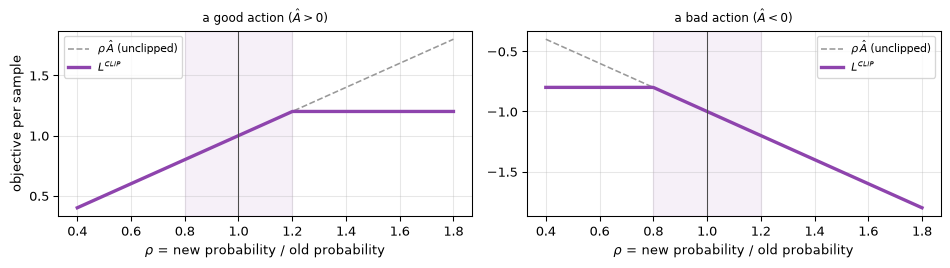

read from the trained model: clip eps 0.2, GAE lambda 0.95, gamma 0.99, 45,721 weights (policy + value network)
log_std after 3 M steps: -2.08 to -1.93 (started at -2.00)

In [3]:
p = policies["random"]
rho = np.linspace(0.4, 1.8, 300)
fig, axes = plt.subplots(1, 2, figsize=(10, 2.9), sharey=False)
for ax, A, title in ((axes[0], 1.0, "a good action ($\\hat A > 0$)"), (axes[1], -1.0, "a bad action ($\\hat A < 0$)")):
    eps = p.clip_range(1.0)
    ax.plot(rho, rho * A, color="0.6", ls="--", lw=1.2, label="$\\rho\\,\\hat A$ (unclipped)")
    ax.plot(rho, np.minimum(rho * A, np.clip(rho, 1 - eps, 1 + eps) * A), color="#8e44ad", lw=2.5, label="$L^{CLIP}$")
    ax.axvspan(1 - eps, 1 + eps, color="#8e44ad", alpha=0.08)
    ax.axvline(1, color="0.3", lw=0.8)
    ax.set_xlabel("$\\rho$ = new probability / old probability"); ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel("objective per sample")
fig.tight_layout(); plt.show()
print(f"read from the trained model: clip eps {p.clip_range(1.0)}, GAE lambda {p.gae_lambda}, gamma {p.gamma}, "
      f"{sum(x.numel() for x in p.policy.parameters()):,} weights (policy + value network)")
print(f"log_std after 3 M steps: {p.policy.log_std.detach().numpy().min():.2f} to "
      f"{p.policy.log_std.detach().numpy().max():.2f} (started at -2.00)")

Left: once an action has become 20 % more likely, pushing further earns
nothing — the purple line goes flat. Right: once it is 20 % less likely,
the same. **Each update may move the policy only a little**, whatever
the batch seemed to say; that is what keeps 3 million noisy steps from
undoing themselves.

------------------------------------------------------------------------

## What the learning curve says

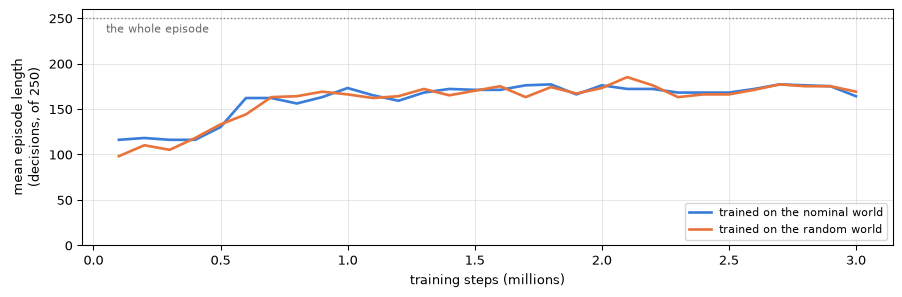

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 3.2))
for name, c in (("nominal", "#3b7dd8"), ("random", "#e8743b")):
    d = np.loadtxt(checkpoint(f"push_{name}.csv"), delimiter=",", skiprows=1)
    ax.plot(d[:, 0] / 1e6, d[:, 2], color=c, lw=2, label=f"trained on the {name} world")
ax.axhline(250, color="0.5", ls=":", lw=1); ax.text(0.05, 244, "the whole episode", fontsize=8, color="0.4", va="top")
ax.set_xlabel("training steps (millions)"); ax.set_ylabel("mean episode length\n(decisions, of 250)")
ax.set_ylim(0, 260); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

It climbs for the first 0.7 million steps and then flattens around 170
of 250. That is not a failure: pushes go up to **200 N**, and no stance
of this robot survives 200 N (MPPI survived it by *stepping* 3 m). The
plateau is the fraction of shoves that can be survived without walking
away.

Week 10’s reading of a curve: *flat is the task’s ceiling, not the
optimiser’s.*

------------------------------------------------------------------------

## Measuring a policy honestly

Training returns are averages over random pushes, random worlds and
noisy actions. To measure, fix everything and count:

In [5]:
def survived(policy, world, push, episodes=10, seed=0):
    """Episodes out of `episodes` still standing after a sideways shove of exactly `push` N."""
    env.world = {k: (v, v) for k, v in world.items()}
    ok = 0
    for k in range(episodes):
        obs, _ = env.reset(seed=seed + k)            # a different crouch and push moment each time
        env.push_force = np.array([0.0, float(push)])     # from the right, exactly `push` newtons
        while True:
            a = np.zeros(12, np.float32) if policy is None else policy.predict(obs, deterministic=True)[0]
            obs, _, terminated, truncated, _ = env.step(a)
            if terminated or truncated:
                break
        ok += not terminated
    return ok

PUSHES = (60, 80, 100, 120)
rows = {"hold the crouch": None, "PPO, nominal world": policies["nominal"], "PPO, randomised world": policies["random"]}
t0 = time.time()
NOMINAL = dict(friction=1.0, mass=0.0, kp=1.0)
table = {name: [survived(p, NOMINAL, f) for f in PUSHES] for name, p in rows.items()}
print(f"episodes survived of 10, nominal world ({time.time() - t0:.0f} s):")
print(f"{'':24s}" + "".join(f"{f:>7} N" for f in PUSHES))
for name, counts in table.items():
    print(f"{name:24s}" + "".join(f"{c:9d}" for c in counts))

episodes survived of 10, nominal world (31 s):
                             60 N     80 N    100 N    120 N
hold the crouch                10        0        0        0
PPO, nominal world             10       10        0        0
PPO, randomised world          10       10        9        1

Deterministic policy (the mean action), sideways shoves as in weeks 7
and 11, ten episodes per cell differing in the moment of the push and
the small random crouch they start from.

------------------------------------------------------------------------

## What ten episodes can tell you

Each cell is a count $k$ out of $n = 10$. Suppose the controller’s true
survival probability at that shove is $p$. If the episodes are
independent, the count follows the **binomial** law:

$$P(k \text{ of } n) = \binom{n}{k}\,p^k (1-p)^{n-k}, \qquad \binom{n}{k} = \frac{n!}{k!\,(n-k)!}$$

In [6]:
from math import comb
def at_least(k, n, p):
    return sum(comb(n, j) * p ** j * (1 - p) ** (n - j) for j in range(k, n + 1))
print(f"{'true survival p':>16s}   P(10 of 10)   P(at least 7 of 10)")
for p in (0.5, 0.7, 0.9, 0.99):
    print(f"{p:16.2f}   {at_least(10, 10, p):11.3f}   {at_least(7, 10, p):19.3f}")

 true survival p   P(10 of 10)   P(at least 7 of 10)
            0.50         0.001                 0.172
            0.70         0.028                 0.650
            0.90         0.349                 0.987
            0.99         0.904                 1.000

- A controller that survives only half the time almost never shows 10
  of 10. So **10/10 means “reliable”**, and a 9/10 next to a 10/10 is
  **not** a difference — both are consistent with $p = 0.9$.
- The lab’s referee passes a limit at **7 of 10**: a controller with
  $p = 0.9$ clears it 99 times in 100, one with $p = 0.5$ about one time
  in six. It is a margin, not a knife edge.

------------------------------------------------------------------------

## What it learned

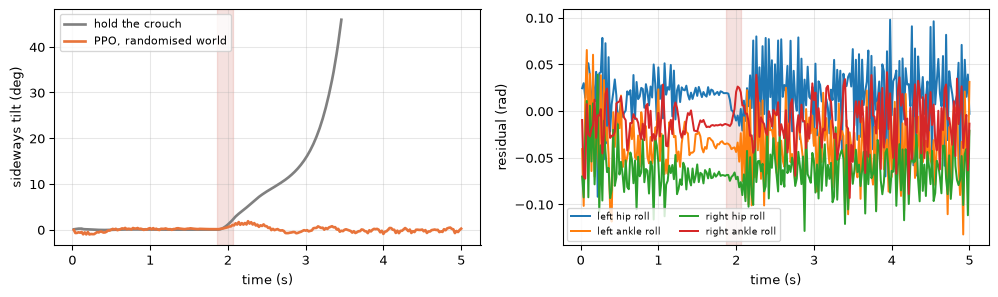

policy: largest tilt 1.9 deg; largest roll residual before the shove 0.118 rad, after it 0.132 rad

In [7]:
def trace(policy, push=80.0, seed=3):
    env.world = {k: (v, v) for k, v in NOMINAL.items()}
    obs, _ = env.reset(seed=seed); env.push_force = np.array([0.0, push]); out = []
    while True:
        a = np.zeros(12, np.float32) if policy is None else policy.predict(obs, deterministic=True)[0]
        obs, _, term, trunc, _ = env.step(a)
        out.append((env.data.time, env.data.qpos[1], np.degrees(np.arcsin(np.clip(obs[1], -1, 1))), a[1], a[5], a[7], a[11]))
        if term or trunc:
            return np.array(out), env.push_time
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2))
for name, p, c in (("hold the crouch", None, "0.5"), ("PPO, randomised world", policies["random"], "#e8743b")):
    tr, t_push = trace(p)
    axes[0].plot(tr[:, 0], tr[:, 2], color=c, lw=2, label=name)
axes[0].axvspan(t_push, t_push + 0.2, color="#c0392b", alpha=0.15)
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("sideways tilt (deg)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
tr, t_push = trace(policies["random"])
for k, lab in ((3, "left hip roll"), (4, "left ankle roll"), (5, "right hip roll"), (6, "right ankle roll")):
    axes[1].plot(tr[:, 0], 0.3 * tr[:, k], lw=1.5, label=lab)
axes[1].axvspan(t_push, t_push + 0.2, color="#c0392b", alpha=0.15)
axes[1].set_xlabel("time (s)"); axes[1].set_ylabel("residual (rad)"); axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()
before = tr[:, 0] < t_push
print(f"policy: largest tilt {np.abs(tr[:, 2]).max():.1f} deg; largest roll residual before the shove "
      f"{0.3 * np.abs(tr[before, 3:7]).max():.3f} rad, after it {0.3 * np.abs(tr[~before, 3:7]).max():.3f} rad")

Left: an 80 N shove. The crouch tips over; the policy’s tilt peaks at
two degrees and comes back. Right: what the policy does with the four
roll joints — it never holds still, correcting by up to 0.12 rad at 50
Hz before the shove, nearly as much as the 0.13 rad after it (printed
above). Whatever it learned, it is not written in a form anyone can read
off the plot: **a learned controller can work without being
explainable**, which is exactly why it has to be measured.

------------------------------------------------------------------------

## Now change the world

The **sim-to-real gap** without a real robot: the policy meets a world
whose physics differs from the one it trained in. Mass, friction and
motor strength are exactly the numbers a real robot gets wrong.

In [8]:
WORLDS = {"nominal": NOMINAL,
          "ice (friction 0.2)": dict(friction=0.2, mass=0.0, kp=1.0),
          "heavy (+15 kg torso)": dict(friction=1.0, mass=15.0, kp=1.0),
          "light (-5 kg torso)": dict(friction=1.0, mass=-5.0, kp=1.0),
          "weak servos (kp x0.6)": dict(friction=1.0, mass=0.0, kp=0.6),
          "stiff servos (kp x1.5)": dict(friction=1.0, mass=0.0, kp=1.5)}
GRID_PUSHES = (0,) + PUSHES
t0 = time.time()
GRID = {}                      # (world, controller) -> survivals at each shove
for wname, w in WORLDS.items():
    for name, p in rows.items():
        if wname == "nominal":             # measured on the previous slide already
            GRID[wname, name] = [survived(p, w, 0)] + table[name]
        else:
            GRID[wname, name] = [survived(p, w, f) for f in GRID_PUSHES]
print(f"6 worlds x 3 controllers x {len(GRID_PUSHES)} shoves x 10 episodes, in {time.time() - t0:.0f} s; "
      "the next slide draws them")

6 worlds x 3 controllers x 5 shoves x 10 episodes, in 204 s; the next slide draws them

------------------------------------------------------------------------

## The whole grid

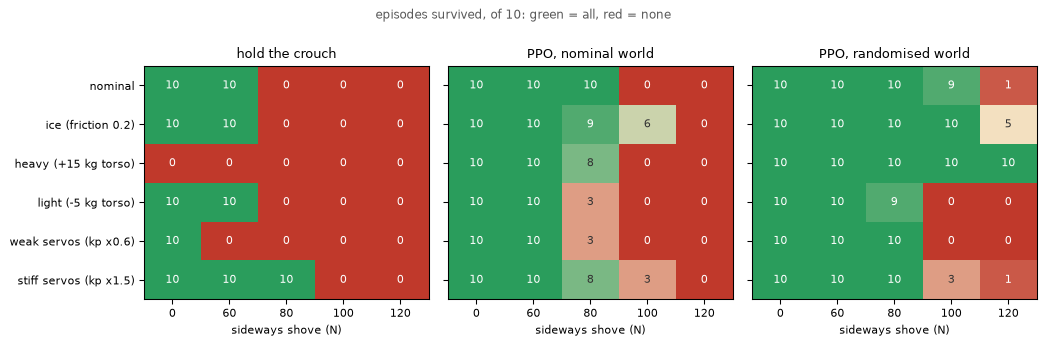

In [9]:
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("survive", ["#c0392b", "#f4e1c1", "#2a9d5c"])
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, name in zip(axes, rows):
    M = np.array([GRID[w, name] for w in WORLDS])
    ax.imshow(M, cmap=cmap, vmin=0, vmax=10, aspect="auto")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, M[i, j], ha="center", va="center", fontsize=8.5,
                    color="white" if M[i, j] <= 2 or M[i, j] >= 9 else "0.2")
    ax.set_xticks(range(len(GRID_PUSHES)), [f"{f}" for f in GRID_PUSHES], fontsize=8)
    ax.set_xlabel("sideways shove (N)", fontsize=8.5); ax.set_title(name, fontsize=9.5)
axes[0].set_yticks(range(len(WORLDS)), list(WORLDS), fontsize=8.5)
fig.suptitle("episodes survived, of 10: green = all, red = none", fontsize=9, color="0.35", y=0.99)
fig.tight_layout(); plt.show()

Each square is one world and one shove, ten episodes. Read a row left to
right: how big a shove that controller takes in that world. Read the
three panels at the same square: which controller to ship to that world.

------------------------------------------------------------------------

## Reading the grid

Four things:

1.  **Hold** has no margin to lose: +15 kg drops it with no shove at all
    (the 0 N column), weak servos at 60 N.
2.  The **nominal policy** takes 80 N 10/10 only in the nominal world
    and on ice. Every change of body — heavier, lighter, weaker, stiffer
    — costs it margin: 8, 3, 3 and 8 of 10 at 80 N.
3.  The **randomised policy** holds 80 N in every world (9 of 10 when
    light), and with +15 kg — outside the −5…+10 range it trained on —
    takes even 120 N.
4.  It is not worse in the nominal world; here it is better.
    **Randomisation has no guaranteed price** — with a small network and
    a hard task it can act as a regulariser. (Week 14 finds a case where
    it does cost accuracy.)

------------------------------------------------------------------------

## Robust to what it trained on

Slide one world parameter at a time through and past the training range,
with the same 80 N shove (the nominal policy’s own limit):

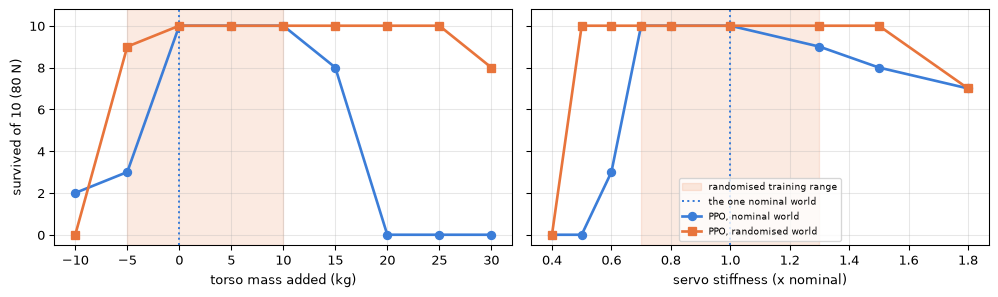

(114 s)

In [10]:
SWEEPS = {"mass": (-10, -5, 0, 5, 10, 15, 20, 25, 30), "kp": (0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.3, 1.5, 1.8)}
t0 = time.time()
sweep = {(k, n): [survived(policies[n], {**NOMINAL, k: v}, 80) for v in vals]
         for k, vals in SWEEPS.items() for n in ("nominal", "random")}
from soc4180.envs import RANDOM_WORLD
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2), sharey=True)
for ax, (k, vals), label in zip(axes, SWEEPS.items(), ("torso mass added (kg)", "servo stiffness (x nominal)")):
    lo, hi = RANDOM_WORLD[k]
    ax.axvspan(lo, hi, color="#e8743b", alpha=0.15, label="randomised training range")
    ax.axvline(NOMINAL[k], color="#3b7dd8", ls=":", lw=1.5, label="the one nominal world")
    ax.plot(vals, sweep[k, "nominal"], "o-", color="#3b7dd8", lw=2, label="PPO, nominal world")
    ax.plot(vals, sweep[k, "random"], "s-", color="#e8743b", lw=2, label="PPO, randomised world")
    ax.set_xlabel(label); ax.set_ylim(-0.5, 10.8); ax.grid(alpha=0.3)
axes[0].set_ylabel("survived of 10 (80 N)"); axes[1].legend(fontsize=7, loc="lower center")
fig.tight_layout(); plt.show()
print(f"({time.time() - t0:.0f} s)")

------------------------------------------------------------------------

## Reading the sweep

- **Blue** — trained in one world, it is good in a neighbourhood of that
  world (0 to +10 kg; stiffness ×0.7 to ×1.0) and falls off on both
  sides: 3 of 10 at −5 kg, none at +20 kg, 3 of 10 at ×0.6.
- **Orange** — trained on the whole shaded band, it holds across the
  band and well past it on the heavy side (10 of 10 up to +25 kg, where
  the band stops at +10) and the weak side (×0.5). But the band has
  **edges**: 5 kg lighter than its lightest training torso (−10 kg) it
  survives **none** of ten, worse than the nominal policy’s two.
- Neither policy was ever told the parameter. The orange one survives
  because its behaviour had to work for every world in the band at once.

**“Robust” is always “robust to something”.** A randomised policy is
robust to the variation it was trained on, plus a margin that must be
measured, not assumed. The real robot is safe only if it lands inside
that region — which is why the range is the engineering decision.

------------------------------------------------------------------------

## Why randomisation works

A policy trained in one world can use *anything* that is true there —
that the torso weighs exactly 7.82 kg, that the knees respond with
exactly this stiffness. Those facts are free to exploit and cost nothing
to learn.

Randomise them, and exploiting them stops paying: the only strategies
that score well are those that work **across** the range. The policy is
forced to become a feedback controller for a *family* of robots.

$$\max_{\color{#3b7dd8}{\pi}} \; \mathbb{E}_{{\color{#e8743b}{\xi}} \sim p(\xi)}\; \mathbb{E}_{\tau \sim {\color{#3b7dd8}{\pi}}, {\color{#e8743b}{\xi}}}\big[{\color{#2a9d5c}{R(\tau)}}\big]$$

where ${\color{#e8743b}{\xi}}$ is the world (mass, friction, gains). The
real robot is then, one hopes, one more sample from
$p({\color{#e8743b}{\xi}})$. The next two slides take this line apart.

------------------------------------------------------------------------

## Domain randomisation, written out

**Step 1 — one world.** In a fixed world ${\color{#e8743b}{\xi}}$, an
episode $\tau$ is random (the shove, the start, the action noise), and
PPO maximises its average return:
$$J({\color{#3b7dd8}{\pi}};\,{\color{#e8743b}{\xi}}) = \mathbb E_{\tau \sim p(\tau \mid {\color{#3b7dd8}{\pi}}, {\color{#e8743b}{\xi}})}\big[{\color{#2a9d5c}{R(\tau)}}\big],
\qquad {\color{#2a9d5c}{R(\tau)}} = \textstyle\sum_{t} \gamma^t {\color{#2a9d5c}{r_t}} .$$

**Step 2 — we do not know the world.** Describe what we believe about it
by a probability distribution $p({\color{#e8743b}{\xi}})$. Here it is
uniform on a box — friction ×0.3…1.2, mass −5…+10 kg, stiffness ×0.7…1.3
— so its density is constant inside the box:
$p({\color{#e8743b}{\xi}}) = 1 / (0.9 \times 15 \times 0.6) = 1/8.1$,
and 0 outside.

**Step 3 — average over worlds** (the law of total expectation):
$$J_{\text{DR}}({\color{#3b7dd8}{\pi}}) = \mathbb E_{{\color{#e8743b}{\xi}} \sim p}\big[J({\color{#3b7dd8}{\pi}};{\color{#e8743b}{\xi}})\big]
= \int p({\color{#e8743b}{\xi}})\; J({\color{#3b7dd8}{\pi}};{\color{#e8743b}{\xi}})\; d{\color{#e8743b}{\xi}} .$$

**Step 4 — PPO already computes this.** Each episode draws a fresh
${\color{#e8743b}{\xi}}$ in `reset`, then a trajectory in that world.
PPO’s batch average over episodes is therefore a Monte-Carlo estimate of
the double average $\mathbb E_{\xi}\,\mathbb E_\tau$. **No change to
PPO** — one line in `reset` changes the objective it optimises.

What it cannot do: Step 3 weighs the worlds by $p$. A world outside the
box has weight **zero** — nothing in training asks the policy to be good
there. The −10 kg point of the sweep, a few slides back, is that zero,
measured.

------------------------------------------------------------------------

## A distribution of worlds, drawn

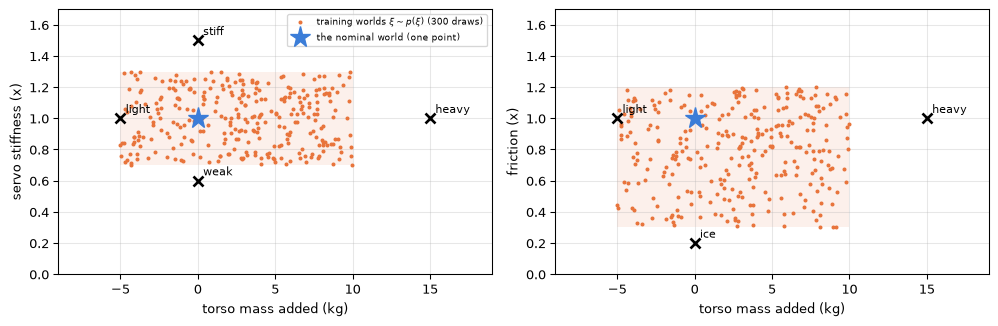

In [11]:
draw = G1PushEnv(world=RANDOM_WORLD)
xi = []
for k in range(300):                                   # 300 training episodes' worlds, as `reset` draws them
    draw.reset(seed=k); xi.append([draw.drawn["friction"], draw.drawn["mass"], draw.drawn["kp"]])
xi = np.array(xi)
tests = {"heavy": (1.0, 15.0, 1.0), "light": (1.0, -5.0, 1.0), "weak": (1.0, 0.0, 0.6),
         "stiff": (1.0, 0.0, 1.5), "ice": (0.2, 0.0, 1.0)}
shown = (("heavy", "light", "weak", "stiff"), ("heavy", "light", "ice"))   # the ones that differ in each view
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.5))
for ax, (i, j), (xl, yl), names in zip(axes, ((1, 2), (1, 0)), (("torso mass added (kg)", "servo stiffness (x)"),
                                                                 ("torso mass added (kg)", "friction (x)")), shown):
    ax.add_patch(plt.Rectangle((RANDOM_WORLD["mass"][0], RANDOM_WORLD[["friction", "mass", "kp"][j]][0]),
                               15.0, np.ptp(RANDOM_WORLD[["friction", "mass", "kp"][j]]),
                               color="#e8743b", alpha=0.10, lw=0))
    ax.plot(xi[:, i], xi[:, j], ".", color="#e8743b", ms=4, label="training worlds $\\xi \\sim p(\\xi)$ (300 draws)")
    ax.plot(0.0, 1.0, "*", color="#3b7dd8", ms=16, label="the nominal world (one point)")
    for name in names:
        w = tests[name]
        ax.plot(w[i], w[j], "kx", ms=8, mew=2); ax.annotate(name, (w[i], w[j]), xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_xlim(-9, 19)
    ax.set_ylim(0.0, 1.7); ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, loc="upper right")
fig.tight_layout(); plt.show()

Orange dots: the worlds the randomised policy trained in; the nominal
policy saw only the blue star. Black crosses: the grid’s test worlds
(each view shows the ones that differ in its two parameters). **Heavy,
weak, stiff and ice lie outside the box**, light on its edge — no
training episode was like them — and the real robot is one more unknown
point, somewhere, that we hope is inside.

------------------------------------------------------------------------

## Where the idea is used

- **Tobin et al., 2017**: randomised textures for vision (week 14).
- **OpenAI, 2019**: a Rubik’s cube solved by a robot hand trained
  entirely in randomised simulation, with the range widened
  automatically as it learned.
- **ETH ANYmal, 2019 onward**: randomised mass, friction, motor models
  and pushes; a policy that walks on the real robot on the first try.

------------------------------------------------------------------------

## What we did not randomise

The list of ways a real G1 differs from ours is longer than three
numbers:

| gap | what it does | how it is usually handled |
|------------------------|------------------------|------------------------|
| **latency** | the action arrives 10–40 ms late | delay the action in simulation |
| **sensor noise, bias** | the IMU drifts (week 6) | add noise and bias to observations |
| **motor model** | torque limits, saturation, heating | a learned actuator network (ANYmal) |
| **contact** | feet, soles, floors | randomised friction, restitution, terrain |
| **the body** | masses, lengths, joint offsets | randomise, or measure (system identification) |

Each is a line in `G1PushEnv.reset` and a range someone must choose. Too
narrow and the gap is not covered; too wide and the task becomes
impossible and the policy learns to be timid. **Choosing the ranges is
the engineering.**

------------------------------------------------------------------------

## Planner against policy

In [12]:
obs, _ = env.reset(seed=0); t0 = time.perf_counter()
for _ in range(1000):
    policies["random"].predict(obs, deterministic=True)
ms = (time.perf_counter() - t0) / 1000 * 1e3
print(f"one policy decision: {ms:.2f} ms on this machine, against 20 ms between decisions")

one policy decision: 0.32 ms on this machine, against 20 ms between decisions

|  | MPPI (week 11) | PPO, randomised |
|------------------------|------------------------|------------------------|
| largest sideways shove survived | **300 N** (by stepping) | 100 N |
| thinking per decision | ~100 ms | **well under 1 ms** (above) |
| model needed at run time | an exact one | none |
| training | none | 16 min on 36 cores |
| a heavier torso | falls if its model is not told | **fine** (trained for it) |

Neither dominates. The planner is general and expensive and trusts its
model; the policy is cheap and robust inside its training distribution
and knows nothing outside it.

**Next week puts them together**: use an expensive expert to *teach* a
cheap student — imitation learning.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/12-robustness/lab_robust.py     # torch + SB3: uv sync --extra rl
```

A game: **the robustness audit**. You are handed three controllers —
hold, PPO nominal, PPO random — and **edit only `audit.py`**: the limits
you measured with `robust.py`, and the controller you would ship. The
referee re-measures every answer live (ten shoves per size, 3× speed,
the shove drawn as an arrow): a limit $L$ passes if it survives 7/10 at
$L$ and fails that at $L + 20$. `audit.py` ships with blanks and scores
0 / 5.

| \# | Question | Measured |
|------------------------|------------------------|------------------------|
| 1–3 | the limit of each controller, nominal world | 60, 80, 100 N |
| 4 | torso +15 kg: the best controller and its limit | random, 120 N (hold falls with no shove) |
| 5 | ship one controller to 20 unknown robots, promise ≥ 80 N | random: 18 of 20; nominal: 14 |

------------------------------------------------------------------------

## Lab class: `robust.py`

``` bash
uv run weeks/12-robustness/robust.py                         # evaluate the shipped nominal policy
uv run weeks/12-robustness/robust.py --policy random
uv run weeks/12-robustness/robust.py --train 300000 --world random --envs 8    # your own, ~3 min
uv run weeks/12-robustness/robust.py --policy random --any-direction
```

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | the environment and its world | `G1PushEnv(world=...)`, `set_world`: `geom_friction`, `body_mass`, `actuator_gainprm`/`biasprm` |
| 2 | train or load | `PPO("MlpPolicy", SubprocVecEnv(...), log_std_init=-2)`, `PPO.load` |
| 3–4 | the grid | `xfrc_applied` via `push_force`, `predict(deterministic=True)` |
| 6 | replay | `launch_viewer(passive=True)` |

------------------------------------------------------------------------

## Exercises

1.  **From the front.** Re-run the grid with `--any-direction`. Which
    direction is hardest, and why would a biped be weaker that way?
2.  **Widen the range.** Train with `kp` over ×0.5 … ×1.5 (edit
    `RANDOM_WORLD`). Does the policy get timid in the nominal world?
3.  **Latency.** Apply every action one decision late (keep the previous
    one in `G1PushEnv.step`). How far does the nominal policy’s limit
    drop? Does training with the delay recover it?
4.  **Sensor noise.** Add Gaussian noise of 0.05 to the gravity vector
    in the observation. Measure both policies. Which one is more robust
    to a gap it was never randomised over?
5.  **The number that matters.** For each world, what is the smallest
    change in that one parameter that costs the nominal policy 20 N of
    margin?

------------------------------------------------------------------------

## Next week

**13 — Imitation.** Two experts we already have: the week-4 walker, and
a policy from today. And one we would like to copy: last week’s planner.
We train students to imitate each, measure which imitations work, and
find the rule that decides: *the expert must be a function of what the
student can see.*